In [124]:
# libraries
import pandas as pd
import numpy as np
import os
import sys
import time

from datasets import load_dataset, load_from_disk
import shutil
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.transforms import Compose
import torchvision.models as models


In [91]:
# check and use correct device
print(f"torch.cuda.is_available: {torch.cuda.is_available()}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


torch.cuda.is_available: False


device(type='cpu')

### DATA LOADING FROM HUGGING FACES

In [92]:
'''
# Download data from HUGGING FACES. The data is publically available

# Once for the entire project
data_dir = '~/car-damage-classifier/data/car_damage'

# Download and save data 
ds = load_dataset('SaiVaibhavS/comprehensive-car-damage')
ds.save_to_disk(data_dir)

# clean cache 
shutil.rmtree('/root/.cache/huggingface')
del ds
'''

"\n# Download data from HUGGING FACES. The data is publically available\n\n# Once for the entire project\ndata_dir = '~/car-damage-classifier/data/car_damage'\n\n# Download and save data \nds = load_dataset('SaiVaibhavS/comprehensive-car-damage')\nds.save_to_disk(data_dir)\n\n# clean cache \nshutil.rmtree('/root/.cache/huggingface')\ndel ds\n"

In [93]:
# This is needed for every session to load the data into notebook
data_dir = '/mnt/mydata/Downloads/Course3_AI_Bootcamp/Deep_Learning/ch13_Project_Car_Damage_Detection/car-damage-classifier/data/car_damage'
ds = load_from_disk(data_dir)
print(ds)


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2300
    })
})


In [94]:
# Unfolding the data structure
print(f"ds['train']: {ds['train']}")
print("-"*20)
print(f"type(ds['train']): {type(ds['train'])}")
print("-"*20)
print(f"ds['train'].num_rows: {ds['train'].num_rows}")
print("-"*20)
print(f"ds['train'].features: {ds['train'].features}")
print("-"*20)
print(f"ds['train'].features['label']: {ds['train'].features['label']}")
print("-"*20)
print(f"ds['train'].features['label'].names: {ds['train'].features['label'].names}")
print("-"*20)
print("-"*20)
print(f"len(ds['train']): { len(ds['train']) }")
print("-"*20)
print(f"ds['train'][0]: { ds['train'][0] }")
print("-"*20)
print(f"ds['train'][0]['image']: { ds['train'][0]['image'] }")
print("-"*20)
print(f"ds['train'][0]['label']: { ds['train'][0]['label'] }")
print("-"*20)
print(f"ds['train'][0]['image'].size: { ds['train'][0]['image'].size }")
print("-"*20)
print(f" MOST IMPORTANTLY, \ndir(ds['train']): {dir(ds['train'])}")

ds['train']: Dataset({
    features: ['image', 'label'],
    num_rows: 2300
})
--------------------
type(ds['train']): <class 'datasets.arrow_dataset.Dataset'>
--------------------
ds['train'].num_rows: 2300
--------------------
ds['train'].features: {'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal'])}
--------------------
ds['train'].features['label']: ClassLabel(names=['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal'])
--------------------
ds['train'].features['label'].names: ['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']
--------------------
--------------------
len(ds['train']): 2300
--------------------
ds['train'][0]: {'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x790C62680430>, 'label': 0}
--------------------
ds['train'][0]['image']: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600

In [95]:
classes = ds['train'].features['label'].names
print(f"classes: {classes}")


classes: ['F_Breakage', 'F_Crushed', 'F_Normal', 'R_Breakage', 'R_Crushed', 'R_Normal']


In [96]:
dataset = ds['train']['image']
print(f"dataset: {dataset}")

labels = ds['train']['label']
print(f"\nlabels: {labels}")

labels_unique = np.unique(labels)
print(f"labels_unique: {labels_unique}")

num_classes = len(labels_unique)
print(f"Number of classes : {num_classes}")

dataset: Column([<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x790C62682290>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x790C626807F0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x790C62680FD0>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x790C62682350>, <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=800x600 at 0x790C626806A0>, ...])

labels: Column([0, 0, 0, 0, 0, ...])
labels_unique: [0 1 2 3 4 5]
Number of classes : 6


In [97]:
# Check image sizes and find the min width and min hight (in pixels) - don;t need to img or img index
L, W = [], []
for i in range( ds['train'].num_rows ):
    l, w = ds['train'][i]['image'].size      
    L.append(l)
    W.append(w)
    
print(f"L.min():{min(L)}, W.min():{min(W)}")
img_L_min = min(L)
img_w_min = min(W)


L.min():300, W.min():225


i: 0, len(idx): 500
First image of this class at index: 0

i: 1, len(idx): 400
First image of this class at index: 500

i: 2, len(idx): 500
First image of this class at index: 900

i: 3, len(idx): 300
First image of this class at index: 1400

i: 4, len(idx): 300
First image of this class at index: 1700

i: 5, len(idx): 300
First image of this class at index: 2000



<Figure size 1200x800 with 0 Axes>

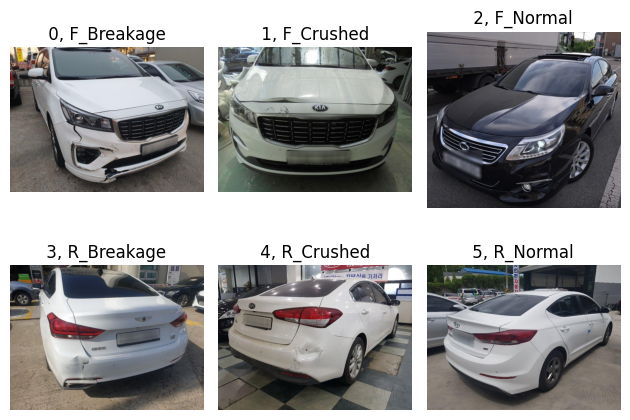

In [98]:
# Visualise the data

plt.figure(figsize = (12, 8))
fig, axes = plt.subplots(2, 3)

for i, ax in enumerate(axes.flat):
    idx = [j for j, k in enumerate(labels) if k==i]
    print(f"i: {i}, len(idx): {len(idx)}")
    
    if idx != None:
        print(f"First image of this class at index: {idx[0]}\n")
        ax.imshow(dataset[ idx[0] ])
        ax.set_title(f" {labels[idx[0]]}, {classes[labels[idx[0]]]} ")
        ax.axis('off')              

plt.tight_layout()
plt.show()


In [99]:
# statified split, 75% for training and 25% for val/test
train_temp = ds['train'].train_test_split(
    train_size         = 0.75,
    test_size          = 0.25,
    seed               = 42,
    stratify_by_column = 'label' 
) 

print(f"train_temp:       {train_temp}")
print(f"type(train_temp): {type(train_temp)}")
print(f"len(train_temp):  {len(train_temp)}")


train_temp:       DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 1725
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 575
    })
})
type(train_temp): <class 'datasets.dataset_dict.DatasetDict'>
len(train_temp):  2


In [100]:
# statified split of the 25% in test, 60%/40% for val/test
val_test = train_temp['test'].train_test_split(
    train_size         = 0.50,
    test_size          = 0.50,
    seed               = 42,
    stratify_by_column = 'label' 
) 

print(f"val_test:       {val_test}")
print(f"type(val_test): {type(val_test)}")
print(f"len(val_test):  {len(val_test)}")


val_test:       DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 287
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 288
    })
})
type(val_test): <class 'datasets.dataset_dict.DatasetDict'>
len(val_test):  2


In [101]:
# verify data split counts
train_ds = train_temp['train']
val_ds   = val_test['train']
test_ds  = val_test['test']

print(f"train_ds: {len(train_ds)}, type(train_ds): {type(train_ds)}")
print(f"val_ds:   {len(val_ds)}  , type(val_ds): {type(val_ds)}"), 
print(f"test_ds:  {len(test_ds)} , type(test_ds): {type(test_ds)}")


train_ds: 1725, type(train_ds): <class 'datasets.arrow_dataset.Dataset'>
val_ds:   287  , type(val_ds): <class 'datasets.arrow_dataset.Dataset'>
test_ds:  288 , type(test_ds): <class 'datasets.arrow_dataset.Dataset'>


In [102]:
# verify class distribution
for split, name in zip([train_ds, val_ds, test_ds],['train', 'val','test']):
    #print(f"split:{split}, \nname:{name}")
    #print("-------")
    
    labels = split['label']
    unique, counts = np.unique(labels, return_counts=True)
    #print(f"unique: {unique}, counts:{counts}")
    #print("---------------------------------")

    print(f"\n{name}: ")
    for a, b in zip(unique, counts):
        print(f"  {classes[a]}: {b}")



train: 
  F_Breakage: 375
  F_Crushed: 300
  F_Normal: 375
  R_Breakage: 225
  R_Crushed: 225
  R_Normal: 225

val: 
  F_Breakage: 62
  F_Crushed: 50
  F_Normal: 62
  R_Breakage: 38
  R_Crushed: 37
  R_Normal: 38

test: 
  F_Breakage: 63
  F_Crushed: 50
  F_Normal: 63
  R_Breakage: 37
  R_Crushed: 38
  R_Normal: 37


In [103]:
# Apply transformation on test, val, train sets seperately

# L.min():300, W.min():225 => so, the images can be resized to 224 x 224

imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

# train_transform processes one image at a atime
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),            
    # transforms.RandomResizedCrop(224),  # resize+crop in one. BUT MAY MISS SOME DAMAGE PORTION, SO AVOID.
    transforms.RandomHorizontalFlip(),    # Flips image horizontally (50% chance)
    transforms.RandomRotation(10),        # Rotates image by up to 10 degrees    
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    
    transforms.ToTensor(),
    transforms.Normalize( mean = imagenet_mean, 
                          std  = imagenet_std ) # ImageNet Params
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),    
    transforms.ToTensor(),
    transforms.Normalize( mean = imagenet_mean, 
                          std  = imagenet_std ) # ImageNet Params
])

# need wrapper fn to apply train_transform as with_transform passes data as a batch dictionary
# batch attributes match the dataset features. 
# i.e. whatever ds['train'].features shows => those are the batch keys
def apply_train_transform(batch):
    transformed_images = []
    for img in batch['image']:
        temp = train_transform( img.convert('RGB') )
        transformed_images.append(temp)
    batch['image'] = transformed_images
    return batch

def apply_val_test_transform(batch):
    transformed_images = []
    for img in batch['image']:
        temp = val_test_transform( img.convert('RGB') )
        transformed_images.append(temp)
    batch['image'] = transformed_images
    return batch
    
# Apply Transformation: with_transform returns a copy (orginal is not changed)
# we cannot directly do => train_ds.with_transform( train_transform )
train_ds = train_ds.with_transform( apply_train_transform ) 
val_ds   = val_ds.with_transform( apply_val_test_transform ) 
test_ds  = val_ds.with_transform( apply_val_test_transform ) 


In [104]:
# Create DataLoader
train_loader = DataLoader( train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader( val_ds,   batch_size=32, shuffle=False)
test_loader  = DataLoader( test_ds,  batch_size=32, shuffle=False)


In [105]:
# HF dataset returns batches as dictionaries {'image': tensor, 'label': tensor}, not tuples as in our previous project
# for images, labels in train_loader: will not work here.
for batch in train_loader:
    images, labels = batch['image'], batch['label']
    print(f"images.shape: {images.shape}")
    print(f"labels.shape: {labels.shape}")
    break

print("---")
print(f"images[0].shape: {images[0].shape}, labels[0]: {labels[0]}, {classes[labels[0]]}")


images.shape: torch.Size([32, 3, 224, 224])
labels.shape: torch.Size([32])
---
images[0].shape: torch.Size([3, 224, 224]), labels[0]: 1, F_Crushed


 type(images[0]): <class 'torch.Tensor'> 


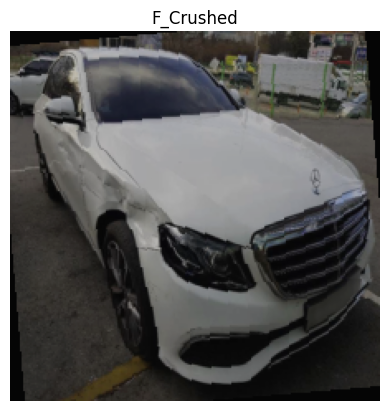

In [106]:
print(f" type(images[0]): {type(images[0])} ")

mean = torch.tensor( imagenet_mean )
std  = torch.tensor( imagenet_std )

img = images[0].permute(1, 2, 0)
img = (img*std + mean).clamp(0, 1)
plt.imshow( img )
plt.title( classes[labels[0]] )
plt.axis('off')
plt.show()


### MODEL 1: TRAINING WITH CNN

In [107]:
in_channels   = 3  # RGB image
out_channels  = 16 # most popular
num_classes   = len(classes) 
dropout_p     = 0.50

class CarClassifierCNN(nn.Module):
    def __init__(self, in_channels, out_channels, num_classes, dropout_p):
        super().__init__()
        
        self.num_classes = num_classes
        
        # BatchNorm in conv layers -> no Dropout needed as Dropout belongs after Flatten in the classifier
        # Conv2d + BatchNorm2d -> always set bias=False, bec BatchNorm does this internally:
        # Step 1: Normalize  => x = (x - mean) / std
        # Step 2: Scale      => x = gamma * x + beta   (beta acts as bias)!
        
        # Conv1
        self.feature1 = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels, kernel_size=3, stride=1, padding=1, bias=False), # 32 x 16 x 224 x 224
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32 x 16 x 112 x 112
        )      
        
        # Conv2
        self.feature2 = nn.Sequential(
            nn.Conv2d(in_channels=out_channels, out_channels=int(out_channels*2), kernel_size=3, stride=1, padding=1, bias=False), # 32 x 32 x 112 x 112
            nn.BatchNorm2d(int(out_channels*2)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32 x 32 x 56 x 56
        )     

        # Conv3
        self.feature3 = nn.Sequential(
            nn.Conv2d(in_channels=int(out_channels*2), out_channels=int(out_channels*4), kernel_size=3, stride=1, padding=1, bias=False), # 32 x 64 x 56 x 56
            nn.BatchNorm2d(int(out_channels*4)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32 x 64 x 28 x 28
        )      
        
        # Conv4
        self.feature4 = nn.Sequential(
            nn.Conv2d(in_channels=int(out_channels*4), out_channels=int(out_channels*8), kernel_size=3, stride=1, padding=1, bias=False), # 32 x 128 x 28 x 28
            nn.BatchNorm2d(int(out_channels*8)),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2), # 32 x 128 x 14 x 14
        )

        # Adaptive pool
        self.pool = nn.AdaptiveAvgPool2d(1) # 32 x 128 x 1 x 1
        
        # Flattening
        self.flatten = nn.Flatten()

        # Classifier
        self.classifier = nn.Sequential(
            nn.Linear( in_features=int(out_channels*8), out_features=int(out_channels*8*2) ),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),
            nn.Linear( in_features=int(out_channels*8*2), out_features=num_classes )
        )
        
    def forward(self, x):
        x = self.feature1(x)
        x = self.feature2(x)
        x = self.feature3(x)
        x = self.feature4(x)
        x = self.pool(x)      # batch x features x 1 x 1]
        x = self.flatten(x)   # batch x features
        x = self.classifier(x)            
        return x        
    

In [117]:
lr          = 0.001
epochs      = 5

# Instantiate the class
model_v1 = CarClassifierCNN( in_channels  = 3, 
                             out_channels = 16, 
                             num_classes  = num_classes, 
                             dropout_p    = dropout_p).to(device)

# Define loss fn or criteria
loss_fn = nn.CrossEntropyLoss()

# Define ADAM optimizer
optimizer = optim.Adam( 
    model_v1.parameters(), 
    lr=lr,               # learning rate         (CAR SPEED)
    betas=(0.9,0.999),   # Momentum of gradient  (HOW SMOOTHLY ACC/BRAKE IS APPLIED)
    weight_decay = 1e-4  # L2 regularization     (FRICTION TO PREVENT SKIDDING)
)

# Define scheduler to update/change learning rate during optimization
scheduler = optim.lr_scheduler.ReduceLROnPlateau( optimizer, 
                                                  mode     = 'min', 
                                                  factor   = 0.1, 
                                                  patience = 3)


In [118]:
# write train_model()
# NOTE: loss.item() = already averaged per image in batch
#       Dividing epoch_loss by len(train_loader) gives average loss per image across full epoch.
def train_model(*,
                epochs:       int,
                model:        torch.nn.Module,
                train_loader: torch.utils.data.DataLoader,
                val_loader:   torch.utils.data.DataLoader,
                loss_fn:      torch.nn.Module,
                optimizer:    torch.optim.Optimizer, 
                scheduler:    torch.optim.lr_scheduler.ReduceLROnPlateau
               ) -> None:
    
    for epoch in range(epochs):
        model_v1.train()
        epoch_loss = 0.0
        
        for i, batch in enumerate(train_loader):
            images, labels = batch['image'].to(device), batch['label'].to(device)

            # forward pass
            outputs = model_v1(images)
            loss    = loss_fn(outputs, labels)
            #loss.item() = sum of losses for 32 images / 32
            
            # backward pass
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            epoch_loss += loss.item() 
            # adding up batch averages
            
            # step 
            optimizer.step()

            # print after 10 iterations of i
            if i%10 == 0:
                print(f"---- Epoch [{epoch+1}/{epochs}], Batch [{i+1}/{len(train_loader)}], Batch_Loss {loss.item():.3f} ")

        # after the batch loop ends, and before next epoch, get validation metric
        val_acc, val_loss = val_model(model=model_v1,
                                     val_loader=val_loader, 
                                     loss_fn=loss_fn)
        
        # update scheduler based on val_loss, and reduce step size if loss is not decreasing
        scheduler.step(val_loss)

        # Get lr value from optimizer for printing
        current_lr = optimizer.param_groups[0]['lr'] 
        
        # Print epoch, val_acc, val_loss
        avg_train_loss = epoch_loss / len(train_loader)
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.3f}, Val Acc: {val_acc:.3f}%, Val Loss: {val_loss:.3f}, LR: {current_lr}")        


In [119]:
# write val_model()
def val_model(*,
             model:      torch.nn.Module,
             val_loader: torch.utils.data.DataLoader,
             loss_fn:    torch.nn.Module,              
             ):
    
    val_loss, correct, total = 0.0, 0, 0
    model_v1.eval()

    with torch.inference_mode():
        for i, batch in enumerate(val_loader):
            images, labels = batch['image'].to(device), batch['label'].to(device)
            
            outputs     = model_v1(images)
            loss        = loss_fn(outputs, labels)
            val_loss   += loss.item()

            predicted   = torch.argmax(outputs, dim=1)
            total      += labels.size(0)
            correct    += (predicted==labels).sum().item() 
            
    avg_loss = val_loss/len(val_loader)
    accuracy = 100*correct/total
            
    return accuracy, avg_loss

In [120]:
start = time.time()

# use 2 of 4 cores so that I can do other work side by side. 
torch.set_num_threads(2) 
train_model( model        = model_v1, 
             epochs       = epochs,             
             train_loader = train_loader,             
             val_loader   = val_loader,             
             loss_fn      = loss_fn, 
             optimizer    = optimizer,
             scheduler    = scheduler             
           )            

print(f"Total time taken to execute execute train_model() is : {(time.time()-start)/60} minutes")


---- Epoch [1/5], Batch [1/54], Batch_Loss 1.772 
---- Epoch [1/5], Batch [11/54], Batch_Loss 1.828 
---- Epoch [1/5], Batch [21/54], Batch_Loss 1.662 
---- Epoch [1/5], Batch [31/54], Batch_Loss 1.523 
---- Epoch [1/5], Batch [41/54], Batch_Loss 1.896 
---- Epoch [1/5], Batch [51/54], Batch_Loss 1.424 
Epoch [1/5], Train Loss: 1.654, Val Acc: 24.739%, Val Loss: 1.749, LR: 0.001
---- Epoch [2/5], Batch [1/54], Batch_Loss 1.498 
---- Epoch [2/5], Batch [11/54], Batch_Loss 1.534 
---- Epoch [2/5], Batch [21/54], Batch_Loss 1.655 
---- Epoch [2/5], Batch [31/54], Batch_Loss 1.685 
---- Epoch [2/5], Batch [41/54], Batch_Loss 1.468 
---- Epoch [2/5], Batch [51/54], Batch_Loss 1.420 
Epoch [2/5], Train Loss: 1.513, Val Acc: 40.418%, Val Loss: 1.376, LR: 0.001
---- Epoch [3/5], Batch [1/54], Batch_Loss 1.381 
---- Epoch [3/5], Batch [11/54], Batch_Loss 1.335 
---- Epoch [3/5], Batch [21/54], Batch_Loss 1.290 
---- Epoch [3/5], Batch [31/54], Batch_Loss 1.221 
---- Epoch [3/5], Batch [41/54], 

In [122]:
# evauate accuracy on TEST data (seperate from train and val data)

val_acc, val_loss = val_model(
    model      = model_v1,
    val_loader = test_loader, # USE TEST DATA
    loss_fn    = loss_fn)

print(f"Accuracy based on test data is : {val_acc:.2f} %")


Accuracy based on test data is : 45.99 %


SUMMARY:
1. MODEL 1: TRAINING WITH CNN RESULTED IN 45.99% ACCURACY 
2. 75/12.5/12.5 % split for training/validation/test data

QUESTIONS IN MY MIND BEFORE GOING AHEAD:
1. QUE: Download models locally or load from repo? ANS: Local download as the direcly directly reading from torchvision.models does not work on my computer.
2. QUE: Load models 1-by-1 or in a dict structire? ANS: Dict structure
3. QUE: Change last FCL for each model and freeze the conv? ANS: Yes, one modifying function per model.
4. QUE: Re-use train/val functions? ANS: Yes
5. QUE: Optimizer only trains unfrozen layers? Yes, need to filter unfrozen layer in optimizer.
   

### MODEL TRAINING WITH TRANSFER LEARNING
##### ResNet18, EfficientNet-B0, MobileNetV3-Small, DenseNet121
